# Student Study Hours & Academic Performance Dashboard
### *This notebook challenges the belief that studying longer guarantees better academic performance.*

Charts produced:
1. Study Hours Distribution by CGPA Group (Box Plot)
2. Study Method vs CGPA (Stacked Bar)
3. Procrastination Level vs CGPA (Grouped Bar)
4. Deadline Management vs CGPA (Grouped Bar)
5. **Stress: Beginning vs End of Semester** *(headline chart)*
6. Procrastination Level vs End-of-Semester Stress (Bar)
7. Study Hours per Day vs Procrastination Level (Bar)
8. Study Hours Before Exam vs Procrastination Level (Bar)
9. Sleep Hours by CGPA Group (Bar)
10. Social Media Usage vs Procrastination Level (Stacked %)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cleaned_dataset.csv')

# ── Palette ──────────────────────────────────────────────────────────────────
BLUE   = '#4A7FBF'
TEAL   = '#2EAD8A'
AMBER  = '#E8A020'
CORAL  = '#E05C3A'
PURPLE = '#7B68C8'
GRAY   = '#9A9890'
LIGHT  = '#F5F4F0'
BG     = '#FAFAF8'

# ── Shared style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': True,
    'axes.grid':        True,
    'axes.grid.axis':   'y',
    'grid.color':       '#E8E6E0',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

def add_subtitle(ax, text):
    ax.text(0, 1.04, text, transform=ax.transAxes,
            fontsize=9.5, color='#6B6960', ha='left')

def finalize(ax, xlabel=None, ylabel=None):
    if xlabel: ax.set_xlabel(xlabel, labelpad=8)
    if ylabel: ax.set_ylabel(ylabel, labelpad=8)
    ax.tick_params(axis='both', length=0)
    ax.spines['bottom'].set_color('#CCCAC4')

print('Dataset loaded:', df.shape)
df.head(3)

Dataset loaded: (103, 20)


,Gender,Course,Study Year,CGPA,Study Days per Week,Study Hours per Day,Study Hours Before Exam,Study Method,Study Schedule,Follow Schedule Frequency,Procrastination Level,Deadline Management,Social Media During Study,Part-Time Job,Work Hours per Week,Study Place,Family Support,Sleep Hours,Stress Level (Beginning of Semester),Stress Level (End of Semester)
0,Male,Bachelor of Education,2,3.5,6,5.5,3.5,Summarizing/making notes,Yes,Always,2,Good,Sometimes,No,0.0,"Library, Room, Campus Study Area",Very Supportive,6.5,2,4
1,Female,Diploma in Computer Science,3,3.5,5,3.5,7.0,Doing practice questions,No,NaN,3,Average,Always,No,0.0,"Library, Room",Very Supportive,4.5,2,4
2,Female,Diploma in Science,2,3.5,7,5.5,7.0,Doing practice questions,Yes,Always,2,Good,Sometimes,No,0.0,Room,Very Supportive,4.5,3,4


---
## Chart 1 — Study Hours Distribution by CGPA Group
**Type:** Box plot  
**Message:** Wide variance in study hours within every CGPA group proves study duration alone doesn't determine performance.

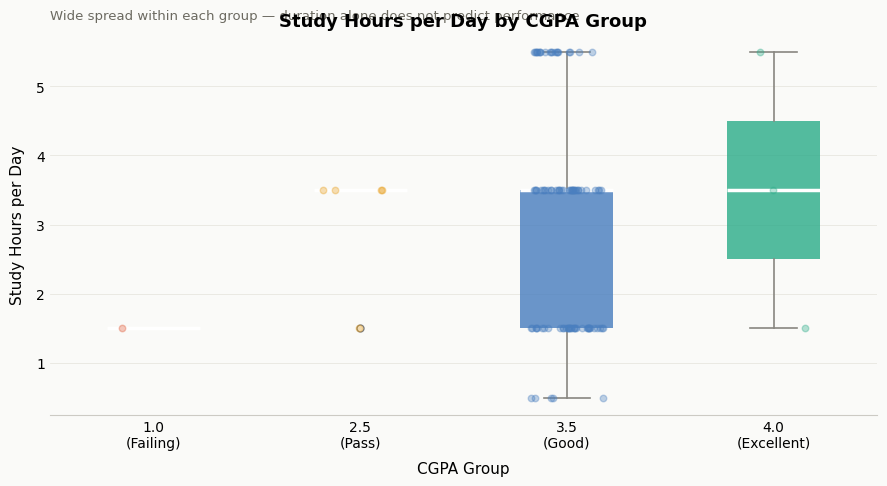

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)

cgpa_order  = [1.0, 2.5, 3.5, 4.0]
cgpa_labels = ['1.0\n(Failing)', '2.5\n(Pass)', '3.5\n(Good)', '4.0\n(Excellent)']
colors      = [CORAL, AMBER, BLUE, TEAL]

data_by_cgpa = [df[df['CGPA'] == g]['Study Hours per Day'].dropna().values
                for g in cgpa_order]

bp = ax.boxplot(
    data_by_cgpa,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2, color='#888680'),
    capprops=dict(linewidth=1.2, color='#888680'),
    flierprops=dict(marker='o', markersize=5, alpha=0.5, linestyle='none'),
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.82)
    patch.set_linewidth(0)

for i, (data, color) in enumerate(zip(data_by_cgpa, colors), start=1):
    jitter = np.random.uniform(-0.18, 0.18, size=len(data))
    ax.scatter(np.full(len(data), i) + jitter, data,
               alpha=0.35, s=22, color=color, zorder=3)

ax.set_xticks(range(1, 5))
ax.set_xticklabels(cgpa_labels)
ax.set_title('Study Hours per Day by CGPA Group')
add_subtitle(ax, 'Wide spread within each group — duration alone does not predict performance')
finalize(ax, xlabel='CGPA Group', ylabel='Study Hours per Day')
plt.tight_layout()
plt.savefig('chart1_study_hours_cgpa_box.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Chart 2 — Study Method vs CGPA
**Type:** Stacked % bar  
**Message:** Active learning methods (practice questions) are more represented at higher CGPA groups.

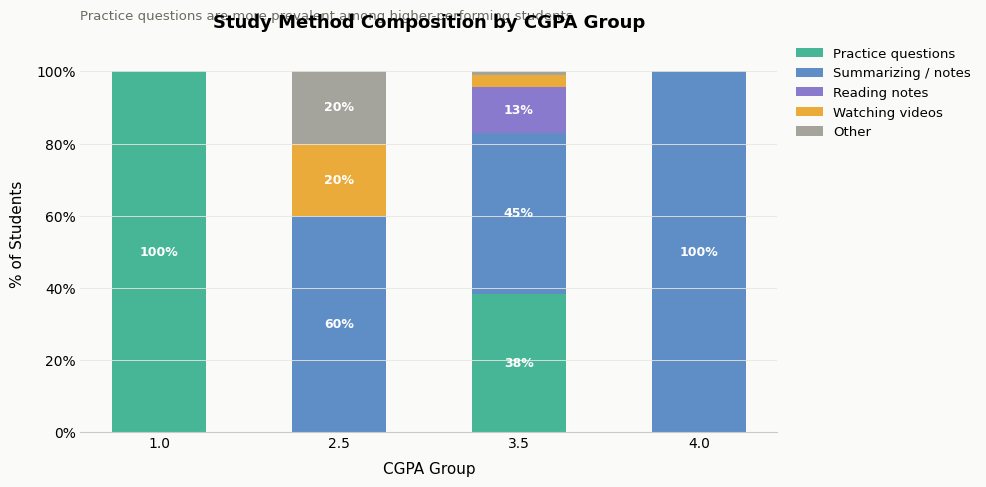

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)

# Consolidate minor categories
method_map = {
    'Summarizing/making notes':          'Summarizing / notes',
    'Doing practice questions':          'Practice questions',
    'Reading lecture notes':             'Reading notes',
    'Watching recorded lectures/videos': 'Watching videos',
    'Ai generated quiz game':            'Other',
    'all of the above':                  'Other',
}
df['Method_Clean'] = df['Study Method'].map(method_map).fillna('Other')

cgpa_labels = ['1.0', '2.5', '3.5', '4.0']
methods = ['Practice questions', 'Summarizing / notes', 'Reading notes', 'Watching videos', 'Other']
method_colors = [TEAL, BLUE, PURPLE, AMBER, GRAY]

ct = pd.crosstab(df['CGPA'], df['Method_Clean'])
ct = ct.reindex(columns=methods, fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(ct_pct))
for method, color in zip(methods, method_colors):
    vals = ct_pct[method].values
    bars = ax.bar(cgpa_labels, vals, bottom=bottom,
                  color=color, alpha=0.88, width=0.52, label=method)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 6:
            ax.text(j, b + v / 2, f'{v:.0f}%',
                    ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    bottom += vals

ax.set_ylim(0, 110)
ax.set_title('Study Method Composition by CGPA Group')
add_subtitle(ax, 'Practice questions are more prevalent among higher-performing students')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9.5)
finalize(ax, xlabel='CGPA Group', ylabel='% of Students')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('chart2_study_method_cgpa.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Chart 3 — Procrastination Level vs CGPA
**Type:** Grouped bar  
**Message:** Lower CGPA students tend toward higher procrastination levels.

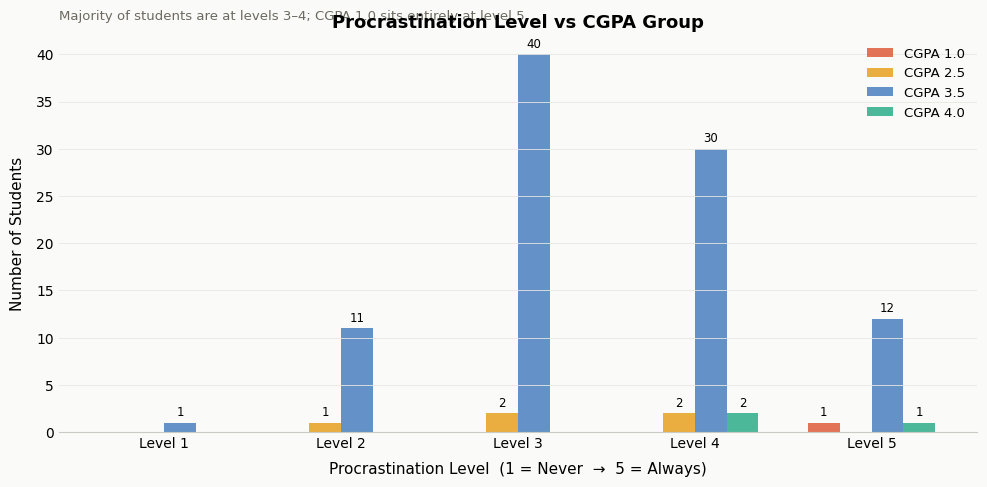

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)

proc_levels = [1, 2, 3, 4, 5]
cgpa_groups = [1.0, 2.5, 3.5, 4.0]
cgpa_colors = [CORAL, AMBER, BLUE, TEAL]
cgpa_labels_short = ['CGPA 1.0', 'CGPA 2.5', 'CGPA 3.5', 'CGPA 4.0']

n_proc   = len(proc_levels)
n_groups = len(cgpa_groups)
bar_w    = 0.18
x        = np.arange(n_proc)

for i, (cgpa, color, label) in enumerate(zip(cgpa_groups, cgpa_colors, cgpa_labels_short)):
    counts = [len(df[(df['CGPA'] == cgpa) & (df['Procrastination Level'] == p)])
              for p in proc_levels]
    offset = (i - n_groups / 2 + 0.5) * bar_w
    bars = ax.bar(x + offset, counts, bar_w,
                  color=color, alpha=0.85, label=label)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
                    str(int(h)), ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels([f'Level {p}' for p in proc_levels])
ax.set_title('Procrastination Level vs CGPA Group')
add_subtitle(ax, 'Majority of students are at levels 3–4; CGPA 1.0 sits entirely at level 5')
ax.legend(frameon=False, fontsize=9.5)
finalize(ax, xlabel='Procrastination Level  (1 = Never  →  5 = Always)', ylabel='Number of Students')
plt.tight_layout()
plt.savefig('chart3_procrastination_cgpa.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Chart 4 — Deadline Management vs CGPA
**Type:** Grouped bar  
**Message:** Students with Good deadline management are absent at low CGPA groups.

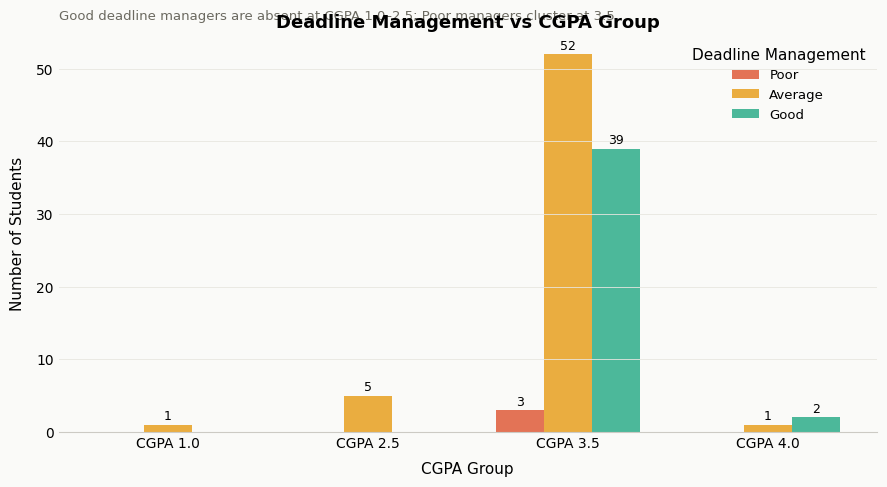

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)

dm_levels  = ['Poor', 'Average', 'Good']
dm_colors  = [CORAL, AMBER, TEAL]
cgpa_groups = [1.0, 2.5, 3.5, 4.0]
x_labels   = ['1.0', '2.5', '3.5', '4.0']

bar_w = 0.24
x     = np.arange(len(cgpa_groups))

for i, (dm, color) in enumerate(zip(dm_levels, dm_colors)):
    counts = [len(df[(df['CGPA'] == g) & (df['Deadline Management'] == dm)])
              for g in cgpa_groups]
    offset = (i - 1) * bar_w
    bars = ax.bar(x + offset, counts, bar_w,
                  color=color, alpha=0.85, label=dm)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                    str(int(h)), ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'CGPA {g}' for g in cgpa_groups])
ax.set_title('Deadline Management vs CGPA Group')
add_subtitle(ax, 'Good deadline managers are absent at CGPA 1.0–2.5; Poor managers cluster at 3.5')
ax.legend(title='Deadline Management', frameon=False, fontsize=9.5)
finalize(ax, xlabel='CGPA Group', ylabel='Number of Students')
plt.tight_layout()
plt.savefig('chart4_deadline_mgmt_cgpa.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Chart 5 — Stress: Beginning vs End of Semester ⭐ *Headline Chart*
**Type:** Paired bar (grouped by procrastination level)  
**Message:** Average stress nearly doubles from 2.46 → 4.20. The higher the procrastination, the steeper the climb.

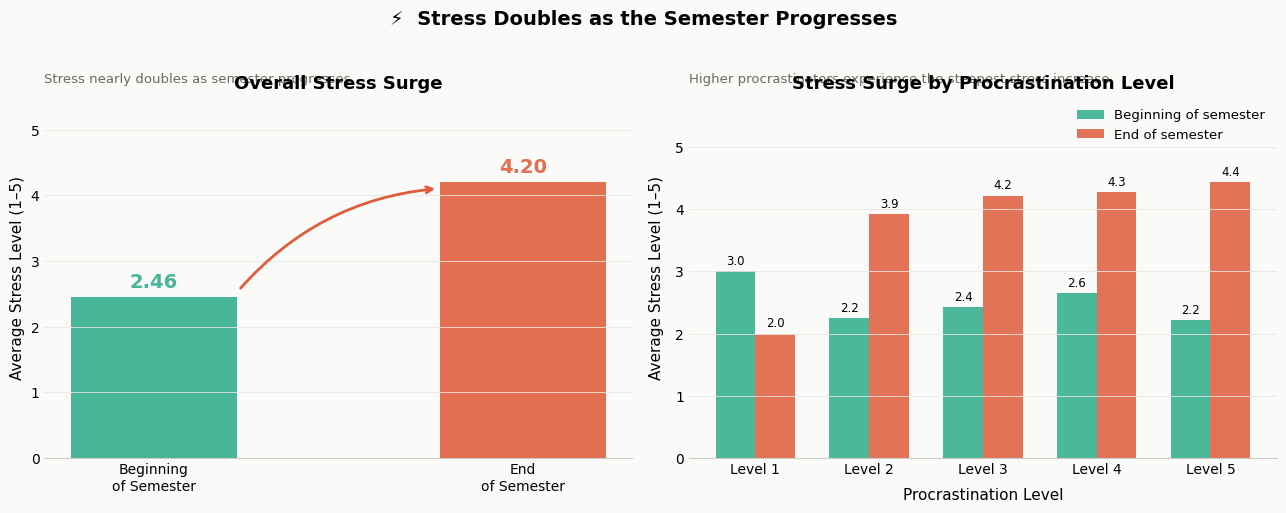

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG)

# ── Left: Overall before/after ──────────────────────────────────────────────
ax = axes[0]
stress_begin = df['Stress Level (Beginning of Semester)'].mean()
stress_end   = df['Stress Level (End of Semester)'].mean()

bars = ax.bar(['Beginning\nof Semester', 'End\nof Semester'],
              [stress_begin, stress_end],
              color=[TEAL, CORAL], alpha=0.88, width=0.45)

for bar, val in zip(bars, [stress_begin, stress_end]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.08,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=14, fontweight='bold',
            color=bar.get_facecolor())

ax.set_ylim(0, 5.5)
ax.set_ylabel('Average Stress Level (1–5)')
ax.set_title('Overall Stress Surge')
add_subtitle(ax, 'Stress nearly doubles as semester progresses')
finalize(ax)

arrow_x = 0.5
ax.annotate('', xy=(1 - 0.23, stress_end - 0.1),
            xytext=(0 + 0.23, stress_begin + 0.1),
            arrowprops=dict(arrowstyle='->', color=CORAL,
                            lw=2, connectionstyle='arc3,rad=-0.2'))

# ── Right: Before/after by procrastination level ─────────────────────────────
ax2 = axes[1]
proc_levels = [1, 2, 3, 4, 5]
avg_begin = [df[df['Procrastination Level'] == p]['Stress Level (Beginning of Semester)'].mean()
             for p in proc_levels]
avg_end   = [df[df['Procrastination Level'] == p]['Stress Level (End of Semester)'].mean()
             for p in proc_levels]

x      = np.arange(len(proc_levels))
bar_w  = 0.35

b1 = ax2.bar(x - bar_w / 2, avg_begin, bar_w, color=TEAL,  alpha=0.85, label='Beginning of semester')
b2 = ax2.bar(x + bar_w / 2, avg_end,   bar_w, color=CORAL, alpha=0.85, label='End of semester')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.06,
             f'{h:.1f}', ha='center', va='bottom', fontsize=8.5)

ax2.set_xticks(x)
ax2.set_xticklabels([f'Level {p}' for p in proc_levels])
ax2.set_ylim(0, 5.8)
ax2.set_title('Stress Surge by Procrastination Level')
add_subtitle(ax2, 'Higher procrastinators experience the steepest stress increase')
ax2.legend(frameon=False, fontsize=9.5)
finalize(ax2, xlabel='Procrastination Level', ylabel='Average Stress Level (1–5)')

plt.suptitle('⚡  Stress Doubles as the Semester Progresses',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart5_stress_surge.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Chart 6 — Procrastination Level vs End-of-Semester Stress
**Type:** Bar chart with trend annotation  
**Message:** Clear linear rise — procrastination level 1 averages stress 2.0; level 5 averages 4.43.

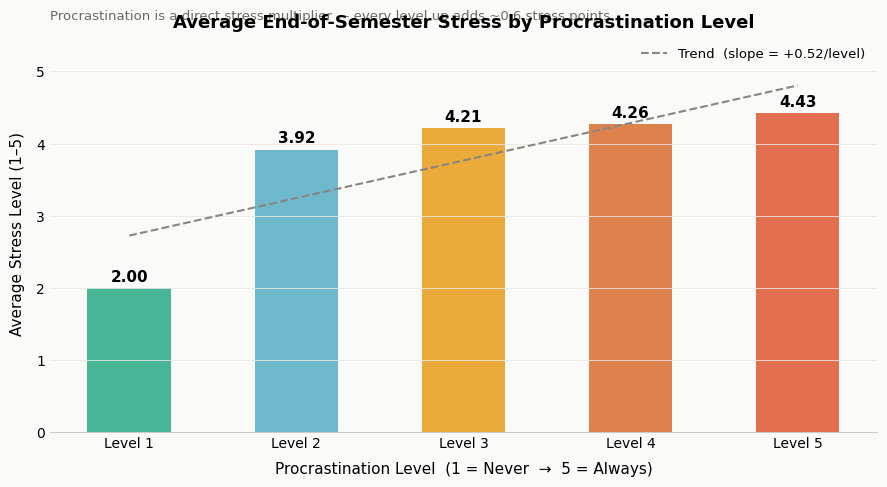

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)

proc_levels = [1, 2, 3, 4, 5]
avg_stress  = [df[df['Procrastination Level'] == p]['Stress Level (End of Semester)'].mean()
               for p in proc_levels]
bar_colors  = [TEAL, '#5BAFC5', AMBER, '#D97035', CORAL]

bars = ax.bar([f'Level {p}' for p in proc_levels],
              avg_stress, color=bar_colors, alpha=0.88, width=0.5)

for bar, val in zip(bars, avg_stress):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

# Trend line
x_vals = np.arange(len(proc_levels))
z = np.polyfit(x_vals, avg_stress, 1)
p = np.poly1d(z)
ax.plot(x_vals, p(x_vals), '--', color='#888680',
        linewidth=1.5, label=f'Trend  (slope = +{z[0]:.2f}/level)')

ax.set_ylim(0, 5.5)
ax.set_title('Average End-of-Semester Stress by Procrastination Level')
add_subtitle(ax, 'Procrastination is a direct stress multiplier — every level up adds ~0.6 stress points')
ax.legend(frameon=False, fontsize=9.5)
finalize(ax, xlabel='Procrastination Level  (1 = Never  →  5 = Always)',
         ylabel='Average Stress Level (1–5)')
plt.tight_layout()
plt.savefig('chart6_procrastination_stress.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Chart 7 — Study Hours per Day vs Procrastination Level
**Type:** Bar chart  
**Message:** High procrastinators study fewer hours per day on average — they front-load nothing, then cram.

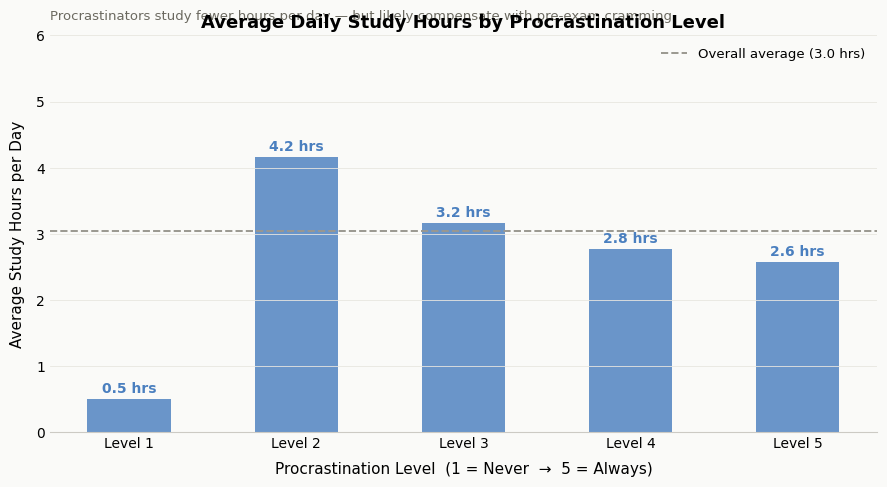

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)

proc_levels = [1, 2, 3, 4, 5]
avg_hours   = [df[df['Procrastination Level'] == p]['Study Hours per Day'].mean()
               for p in proc_levels]

bars = ax.bar([f'Level {p}' for p in proc_levels],
              avg_hours, color=BLUE, alpha=0.82, width=0.5)

for bar, val in zip(bars, avg_hours):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{val:.1f} hrs', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=BLUE)

overall_avg = df['Study Hours per Day'].mean()
ax.axhline(overall_avg, color=GRAY, linestyle='--', linewidth=1.4,
           label=f'Overall average ({overall_avg:.1f} hrs)')

ax.set_ylim(0, 6)
ax.set_title('Average Daily Study Hours by Procrastination Level')
add_subtitle(ax, 'Procrastinators study fewer hours per day — but likely compensate with pre-exam cramming')
ax.legend(frameon=False, fontsize=9.5)
finalize(ax, xlabel='Procrastination Level  (1 = Never  →  5 = Always)',
         ylabel='Average Study Hours per Day')
plt.tight_layout()
plt.savefig('chart7_study_hours_procrastination.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Chart 8 — Study Hours Before Exam vs Procrastination Level
**Type:** Bar chart  
**Message:** High procrastinators cram more hours before exams — confirming the pull-all-nighter pattern.

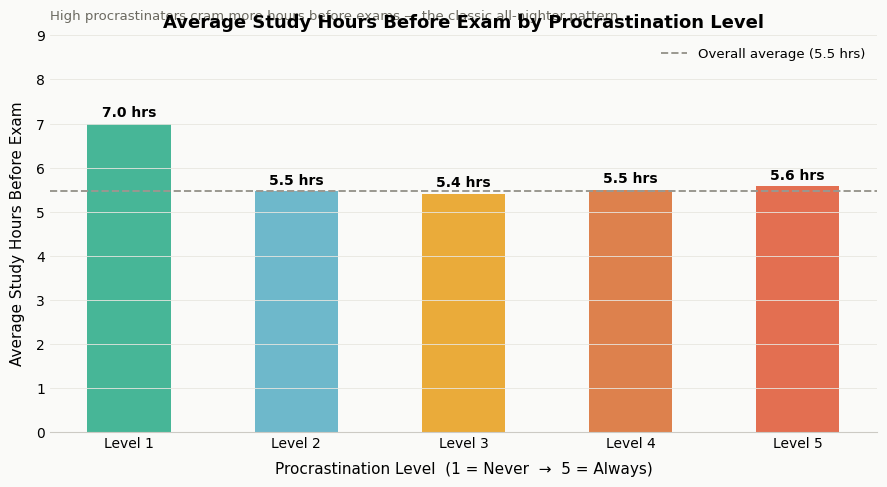

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)

proc_levels     = [1, 2, 3, 4, 5]
avg_exam_hours  = [df[df['Procrastination Level'] == p]['Study Hours Before Exam'].mean()
                   for p in proc_levels]
bar_colors = [TEAL, '#5BAFC5', AMBER, '#D97035', CORAL]

bars = ax.bar([f'Level {p}' for p in proc_levels],
              avg_exam_hours, color=bar_colors, alpha=0.88, width=0.5)

for bar, val in zip(bars, avg_exam_hours):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{val:.1f} hrs', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

overall_avg = df['Study Hours Before Exam'].mean()
ax.axhline(overall_avg, color=GRAY, linestyle='--', linewidth=1.4,
           label=f'Overall average ({overall_avg:.1f} hrs)')

ax.set_ylim(0, df['Study Hours Before Exam'].max() + 2)
ax.set_title('Average Study Hours Before Exam by Procrastination Level')
add_subtitle(ax, 'High procrastinators cram more hours before exams — the classic all-nighter pattern')
ax.legend(frameon=False, fontsize=9.5)
finalize(ax, xlabel='Procrastination Level  (1 = Never  →  5 = Always)',
         ylabel='Average Study Hours Before Exam')
plt.tight_layout()
plt.savefig('chart8_exam_hours_procrastination.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Chart 9 — Sleep Hours by CGPA Group
**Type:** Bar chart with error bars  
**Message:** Higher CGPA students sleep more — countering the all-nighter myth with a wellbeing angle.

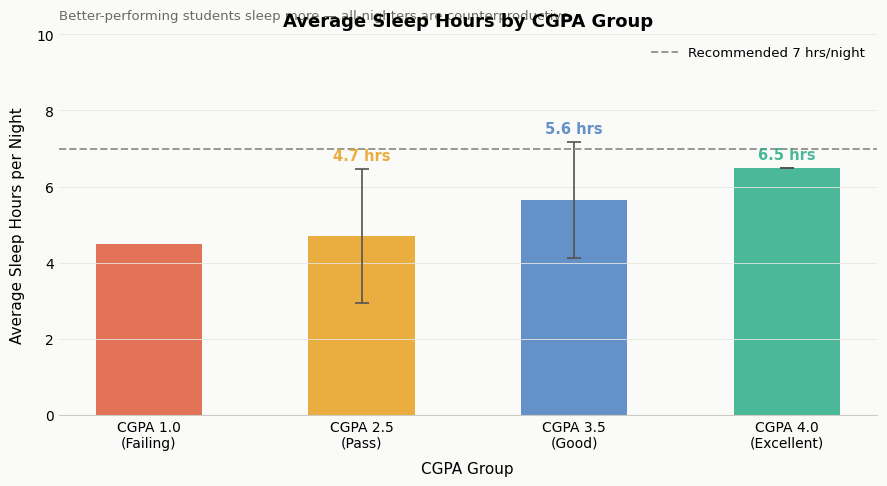

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)

cgpa_groups = [1.0, 2.5, 3.5, 4.0]
cgpa_labels = ['CGPA 1.0\n(Failing)', 'CGPA 2.5\n(Pass)', 'CGPA 3.5\n(Good)', 'CGPA 4.0\n(Excellent)']
colors      = [CORAL, AMBER, BLUE, TEAL]

avgs = [df[df['CGPA'] == g]['Sleep Hours'].mean()  for g in cgpa_groups]
stds = [df[df['CGPA'] == g]['Sleep Hours'].std()   for g in cgpa_groups]

bars = ax.bar(cgpa_labels, avgs,
              color=colors, alpha=0.85, width=0.5,
              yerr=stds, capsize=5,
              error_kw=dict(elinewidth=1.2, ecolor='#555350', capthick=1.2))

for bar, val, std in zip(bars, avgs, stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + std + 0.15,
            f'{val:.1f} hrs', ha='center', va='bottom',
            fontsize=10.5, fontweight='bold',
            color=bar.get_facecolor())

recommended = 7
ax.axhline(recommended, color=GRAY, linestyle='--', linewidth=1.4,
           label='Recommended 7 hrs/night')

ax.set_ylim(0, 10)
ax.set_title('Average Sleep Hours by CGPA Group')
add_subtitle(ax, 'Better-performing students sleep more — all-nighters are counterproductive')
ax.legend(frameon=False, fontsize=9.5)
finalize(ax, xlabel='CGPA Group', ylabel='Average Sleep Hours per Night')
plt.tight_layout()
plt.savefig('chart9_sleep_cgpa.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Chart 10 — Social Media Usage vs Procrastination Level
**Type:** 100% stacked bar  
**Message:** "Always" social media users skew toward higher procrastination — distraction feeds the habit loop.

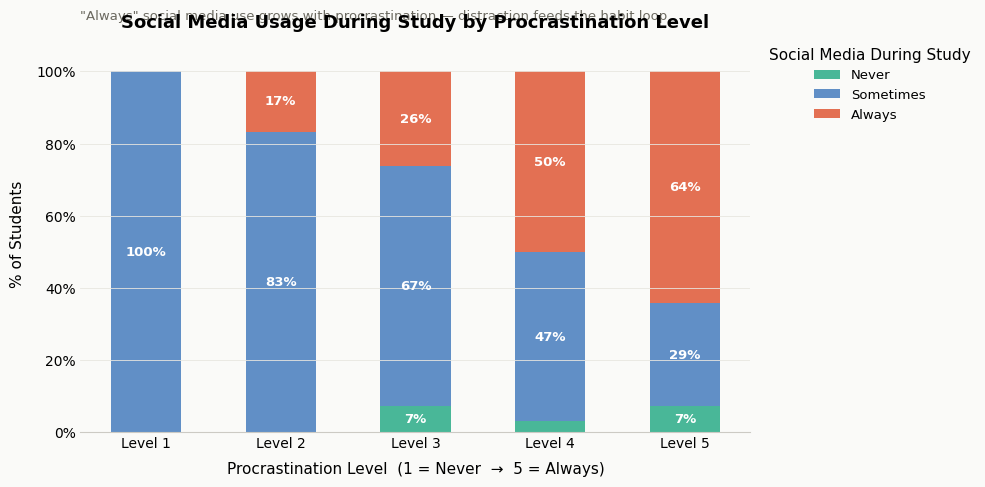

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)

proc_levels = [1, 2, 3, 4, 5]
sm_cats     = ['Never', 'Sometimes', 'Always']
sm_colors   = [TEAL, BLUE, CORAL]

ct = pd.crosstab(df['Procrastination Level'], df['Social Media During Study'])
ct = ct.reindex(columns=sm_cats, fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

x_labels = [f'Level {p}' for p in proc_levels]
bottom = np.zeros(len(proc_levels))

for sm, color in zip(sm_cats, sm_colors):
    vals = ct_pct[sm].values
    ax.bar(x_labels, vals, bottom=bottom,
           color=color, alpha=0.87, width=0.52, label=sm)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 7:
            ax.text(j, b + v / 2, f'{v:.0f}%',
                    ha='center', va='center', fontsize=9.5,
                    color='white', fontweight='bold')
    bottom += vals

ax.set_ylim(0, 110)
ax.set_title('Social Media Usage During Study by Procrastination Level')
add_subtitle(ax, '"Always" social media use grows with procrastination — distraction feeds the habit loop')
ax.legend(title='Social Media During Study',
          loc='upper left', bbox_to_anchor=(1.01, 1),
          frameon=False, fontsize=9.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
finalize(ax, xlabel='Procrastination Level  (1 = Never  →  5 = Always)',
         ylabel='% of Students')
plt.tight_layout()
plt.savefig('chart10_social_media_procrastination.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary Dashboard — All 10 Charts in One Figure

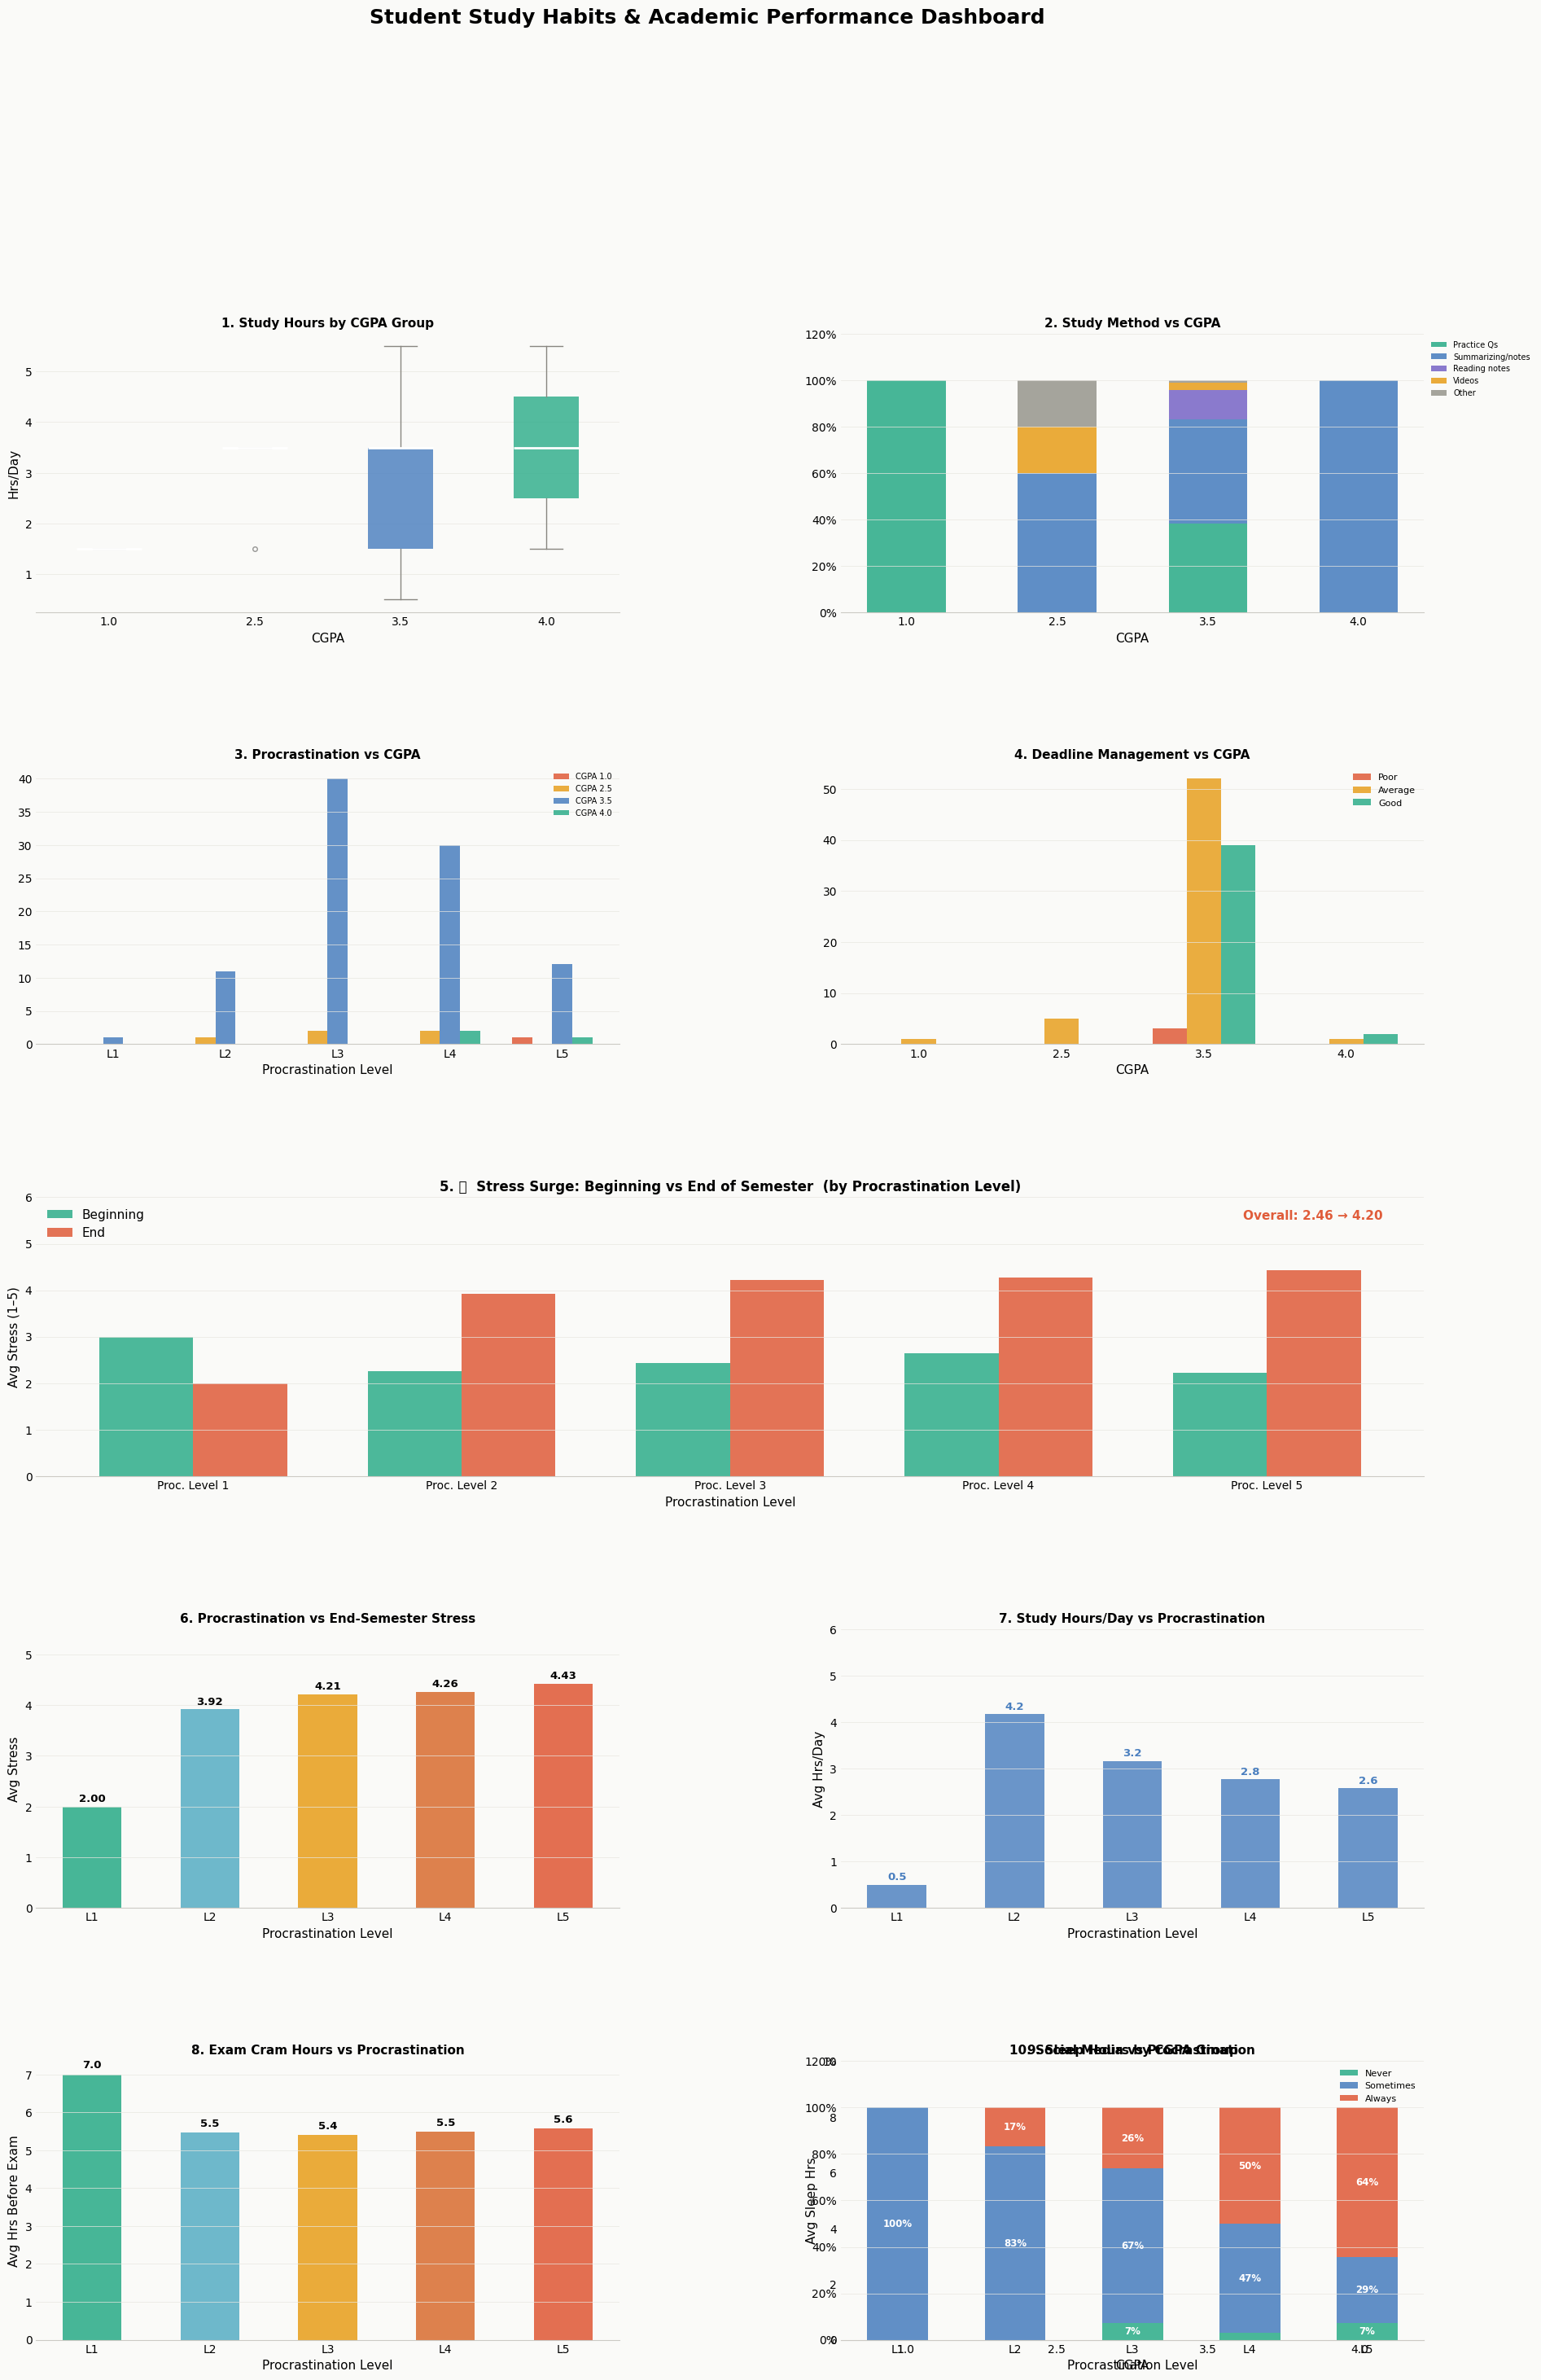

All charts saved.


In [12]:
fig = plt.figure(figsize=(22, 32))
fig.patch.set_facecolor(BG)
gs  = GridSpec(5, 2, figure=fig, hspace=0.55, wspace=0.38)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[2, :]),   # Chart 5 spans full width (headline)
    fig.add_subplot(gs[3, 0]),
    fig.add_subplot(gs[3, 1]),
    fig.add_subplot(gs[4, 0]),
    fig.add_subplot(gs[4, 1]),
]

# ── Helper to re-draw each chart on a given axis ──────────────────────────────

def draw_box(ax):
    cgpa_order = [1.0, 2.5, 3.5, 4.0]
    colors     = [CORAL, AMBER, BLUE, TEAL]
    data_by    = [df[df['CGPA'] == g]['Study Hours per Day'].dropna().values for g in cgpa_order]
    bp = ax.boxplot(data_by, patch_artist=True, widths=0.45,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=1, color='#888680'),
                    capprops=dict(linewidth=1, color='#888680'),
                    flierprops=dict(marker='o', markersize=4, alpha=0.4, linestyle='none'))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.82); patch.set_linewidth(0)
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(['1.0', '2.5', '3.5', '4.0'])
    ax.set_title('1. Study Hours by CGPA Group', fontsize=11)
    ax.set_xlabel('CGPA'); ax.set_ylabel('Hrs/Day')

def draw_method(ax):
    method_map = {'Summarizing/making notes':'Summarizing/notes',
                  'Doing practice questions':'Practice Qs',
                  'Reading lecture notes':'Reading notes',
                  'Watching recorded lectures/videos':'Videos',
                  'Ai generated quiz game':'Other','all of the above':'Other'}
    df['MC'] = df['Study Method'].map(method_map).fillna('Other')
    methods = ['Practice Qs','Summarizing/notes','Reading notes','Videos','Other']
    mc      = [TEAL, BLUE, PURPLE, AMBER, GRAY]
    ct = pd.crosstab(df['CGPA'], df['MC']).reindex(columns=methods, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    bot = np.zeros(4)
    xl  = ['1.0','2.5','3.5','4.0']
    for m, c in zip(methods, mc):
        ax.bar(xl, ct_pct[m].values, bottom=bot, color=c, alpha=0.88, width=0.52, label=m)
        bot += ct_pct[m].values
    ax.set_ylim(0, 120); ax.set_title('2. Study Method vs CGPA', fontsize=11)
    ax.set_xlabel('CGPA'); ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=7, frameon=False, loc='upper left', bbox_to_anchor=(1,1))

def draw_procrastination_cgpa(ax):
    pl = [1,2,3,4,5]; cg = [1.0,2.5,3.5,4.0]; cc = [CORAL,AMBER,BLUE,TEAL]
    bw = 0.18; x = np.arange(5)
    for i,(g,c) in enumerate(zip(cg,cc)):
        counts = [len(df[(df['CGPA']==g)&(df['Procrastination Level']==p)]) for p in pl]
        ax.bar(x+(i-2)*bw, counts, bw, color=c, alpha=0.85, label=f'CGPA {g}')
    ax.set_xticks(x); ax.set_xticklabels([f'L{p}' for p in pl])
    ax.set_title('3. Procrastination vs CGPA', fontsize=11)
    ax.set_xlabel('Procrastination Level'); ax.legend(fontsize=7, frameon=False)

def draw_deadline(ax):
    dm_l=['Poor','Average','Good']; dm_c=[CORAL,AMBER,TEAL]; cg=[1.0,2.5,3.5,4.0]
    bw=0.24; x=np.arange(4)
    for i,(dm,c) in enumerate(zip(dm_l,dm_c)):
        counts=[len(df[(df['CGPA']==g)&(df['Deadline Management']==dm)]) for g in cg]
        ax.bar(x+(i-1)*bw, counts, bw, color=c, alpha=0.85, label=dm)
    ax.set_xticks(x); ax.set_xticklabels([f'{g}' for g in cg])
    ax.set_title('4. Deadline Management vs CGPA', fontsize=11)
    ax.set_xlabel('CGPA'); ax.legend(fontsize=8, frameon=False)

def draw_stress_headline(ax):
    pl=[1,2,3,4,5]
    ab=[df[df['Procrastination Level']==p]['Stress Level (Beginning of Semester)'].mean() for p in pl]
    ae=[df[df['Procrastination Level']==p]['Stress Level (End of Semester)'].mean() for p in pl]
    x=np.arange(5); bw=0.35
    ax.bar(x-bw/2, ab, bw, color=TEAL, alpha=0.85, label='Beginning')
    ax.bar(x+bw/2, ae, bw, color=CORAL, alpha=0.85, label='End')
    ax.set_xticks(x); ax.set_xticklabels([f'Proc. Level {p}' for p in pl])
    ax.set_ylim(0,6); ax.set_title('5. ⭐  Stress Surge: Beginning vs End of Semester  (by Procrastination Level)', fontsize=12)
    ax.set_xlabel('Procrastination Level'); ax.set_ylabel('Avg Stress (1–5)')
    ax.legend(frameon=False)
    sb=df['Stress Level (Beginning of Semester)'].mean()
    se=df['Stress Level (End of Semester)'].mean()
    ax.text(0.97,0.92,f'Overall: {sb:.2f} → {se:.2f}',
            transform=ax.transAxes, ha='right', fontsize=11,
            color=CORAL, fontweight='bold')

def draw_proc_stress(ax):
    pl=[1,2,3,4,5]
    av=[df[df['Procrastination Level']==p]['Stress Level (End of Semester)'].mean() for p in pl]
    bc=[TEAL,'#5BAFC5',AMBER,'#D97035',CORAL]
    ax.bar([f'L{p}' for p in pl], av, color=bc, alpha=0.88, width=0.5)
    for i,(v,c) in enumerate(zip(av,bc)):
        ax.text(i, v+0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    ax.set_ylim(0,5.5); ax.set_title('6. Procrastination vs End-Semester Stress', fontsize=11)
    ax.set_xlabel('Procrastination Level'); ax.set_ylabel('Avg Stress')

def draw_study_proc(ax):
    pl=[1,2,3,4,5]
    ah=[df[df['Procrastination Level']==p]['Study Hours per Day'].mean() for p in pl]
    ax.bar([f'L{p}' for p in pl], ah, color=BLUE, alpha=0.82, width=0.5)
    for i,v in enumerate(ah):
        ax.text(i, v+0.05, f'{v:.1f}', ha='center', va='bottom', fontsize=9.5, color=BLUE, fontweight='bold')
    ax.set_ylim(0,6); ax.set_title('7. Study Hours/Day vs Procrastination', fontsize=11)
    ax.set_xlabel('Procrastination Level'); ax.set_ylabel('Avg Hrs/Day')

def draw_exam_proc(ax):
    pl=[1,2,3,4,5]
    ae=[df[df['Procrastination Level']==p]['Study Hours Before Exam'].mean() for p in pl]
    bc=[TEAL,'#5BAFC5',AMBER,'#D97035',CORAL]
    ax.bar([f'L{p}' for p in pl], ae, color=bc, alpha=0.88, width=0.5)
    for i,v in enumerate(ae):
        ax.text(i, v+0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    ax.set_title('8. Exam Cram Hours vs Procrastination', fontsize=11)
    ax.set_xlabel('Procrastination Level'); ax.set_ylabel('Avg Hrs Before Exam')

def draw_sleep(ax):
    cg=[1.0,2.5,3.5,4.0]; cc=[CORAL,AMBER,BLUE,TEAL]
    av=[df[df['CGPA']==g]['Sleep Hours'].mean() for g in cg]
    sd=[df[df['CGPA']==g]['Sleep Hours'].std()  for g in cg]
    ax.bar([f'{g}' for g in cg], av, color=cc, alpha=0.85, width=0.5,
           yerr=sd, capsize=4, error_kw=dict(elinewidth=1, ecolor='#555350'))
    for i,(v,s) in enumerate(zip(av,sd)):
        ax.text(i, v+s+0.15, f'{v:.1f}h', ha='center', va='bottom',
                fontsize=9.5, fontweight='bold')
    ax.axhline(7, color=GRAY, linestyle='--', linewidth=1.2, label='7 hrs recommended')
    ax.set_ylim(0,10); ax.set_title('9. Sleep Hours by CGPA Group', fontsize=11)
    ax.set_xlabel('CGPA'); ax.set_ylabel('Avg Sleep Hrs'); ax.legend(fontsize=8, frameon=False)

def draw_social(ax):
    pl=[1,2,3,4,5]; sc=['Never','Sometimes','Always']; cc=[TEAL,BLUE,CORAL]
    ct=pd.crosstab(df['Procrastination Level'],df['Social Media During Study']).reindex(columns=sc,fill_value=0)
    ct_pct=ct.div(ct.sum(axis=1),axis=0)*100
    bot=np.zeros(5)
    for s,c in zip(sc,cc):
        vals=ct_pct[s].values
        ax.bar([f'L{p}' for p in pl], vals, bottom=bot, color=c, alpha=0.87, width=0.52, label=s)
        for j,(v,b) in enumerate(zip(vals,bot)):
            if v>7:
                ax.text(j,b+v/2,f'{v:.0f}%',ha='center',va='center',
                        fontsize=8.5,color='white',fontweight='bold')
        bot+=vals
    ax.set_ylim(0,120); ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title('10. Social Media vs Procrastination', fontsize=11)
    ax.set_xlabel('Procrastination Level'); ax.legend(fontsize=8, frameon=False)

# ── Draw all ───────────────────────────────────────────────────────────────────
draw_box(axes[0])
draw_method(axes[1])
draw_procrastination_cgpa(axes[2])
draw_deadline(axes[3])
draw_stress_headline(axes[4])
draw_proc_stress(axes[5])
draw_study_proc(axes[6])
draw_exam_proc(axes[7])
draw_sleep(axes[8])

# Chart 10 needs its own subplot in the last row
ax10 = fig.add_subplot(gs[4, 1])
draw_social(ax10)

for a in fig.axes:
    a.tick_params(length=0)
    for sp in ['top','right','left']:
        a.spines[sp].set_visible(False)
    a.spines['bottom'].set_color('#CCCAC4')
    a.set_facecolor(BG)
    a.grid(axis='y', color='#E8E6E0', linewidth=0.5)

fig.suptitle('Student Study Habits & Academic Performance Dashboard',
             fontsize=18, fontweight='bold', y=1.005)

plt.savefig('dashboard_all_charts.png', dpi=150, bbox_inches='tight',
            facecolor=BG)
plt.show()
print('All charts saved.')